# Confiabilidad y Riesgo

**Programa:** Maestría en Ingeniería Eléctrica  
**Profesor:** Sebastián Aguirre Vargas  
**Institución:** Universidad Tecnológica de Pereira  
**Año:** 2026

## Análisis exploratorio de datos

**EDA** significa análisis exploratorio de datos: observar los datos antes de tomar decisiones.


## 1. Datos de ejemplo



In [106]:
import pandas as pd  # Importa pandas y permite usar el nombre corto pd.
from IPython.display import display  # Permite mostrar las tablas dentro del notebook.


In [107]:
datos = {  # Crea un diccionario: cada nombre será una columna de la tabla.
    "cliente_id": ["C001", "C002", "C003", "C004", "C005", "C006", "C007", "C008", "C009", "C010", "C011", "C012", "C013", "C014", "C015", "C016"],  # Identifica a los 16 clientes.
    "edad": ["29", "41", "", "35", "52", "28", " 44 ", "31", "39", "60", "27", "48", "33", "?", "55", "36"],  # Guarda edades como texto e incluye dos datos faltantes.
    "ingreso_mensual": ["$2,500", "$4,100", None, "$3,500", "$6,800", "$2,200", "$4,900", "$2,900", "$3,800", "$25,000", "$2,100", "$5,600", "N/A", "$3,100", "$7,200", "$3,600"],  # Guarda ingresos con símbolos e incluye un faltante y un valor extremo.
    "compras_ult_6m": [4, 8, 5, 6, 12, 3, 9, 4, 7, 15, 2, 10, 5, None, 11, 6],  # Guarda las compras de los últimos seis meses; None representa un dato faltante.
    "canal": ["Web", "Tienda", "App", " web ", "APP", "Tienda", "Web", "App", "Tienda", "Web", "App", None, "Tienda", "WEB", "App", "Tienda"],  # Guarda el canal de compra con diferencias de escritura y un faltante.
    "region": ["Norte", "Sur", "Centro", "Norte", "Sur", "Centro", "Norte", "Centro", "Sur", "Norte", "Centro", "Sur", "Norte", "Centro", None, "Sur"],  # Guarda la región de cada cliente e incluye un faltante.
    "satisfaccion": ["media", "alta", "media", "baja", "alta", "baja", "alta", "media", "media", "alta", "baja", "alta", "media", None, "alta", "baja"],  # Guarda niveles de satisfacción e incluye un faltante.
    "fecha_alta": ["2024-01-15", "2022-06-03", "2023-11-20", "2025-02-10", "2021-08-25", "2025-05-12", "2022-12-01", "2024-07-18", "2023-03-09", "2020-10-30", "2025-06-22", "2021-04-17", "2024-09-11", "fecha inválida", "2020-02-29", "2023-12-05"],  # Guarda fechas como texto e incluye una fecha inválida.
    "Servicio": ["no", "no", "si", "si", "no", "si", "no", "si", "no", "no", "si", "no", "si", "si", "no", "si"],  # Indica si cada cliente dejó el servicio.
}
df = pd.DataFrame(datos)  # Convierte el diccionario en una tabla de pandas.
fila_repetida = df.iloc[[3]]  # Selecciona la cuarta fila como una tabla de una sola fila.
df = pd.concat([df, fila_repetida], ignore_index=True)  # Agrega la fila repetida y numera nuevamente las filas.
display(df.head())  # Muestra las primeras cinco filas de la tabla.


,cliente_id,edad,ingreso_mensual,compras_ult_6m,canal,region,satisfaccion,fecha_alta,Servicio
0,C001,29,"$2,500",4.0,Web,Norte,media,2024-01-15,no
1,C002,41,"$4,100",8.0,Tienda,Sur,alta,2022-06-03,no
2,C003,,NaN,5.0,App,Centro,media,2023-11-20,si
3,C004,35,"$3,500",6.0,web,Norte,baja,2025-02-10,si
4,C005,52,"$6,800",12.0,APP,Sur,alta,2021-08-25,no


## 2. Inspección inicial

Primero revisamos el tamaño de la tabla, los tipos de datos y los problemas visibles.
`df` será la tabla original; después trabajaremos con una copia.


In [108]:
print("Filas y columnas:", df.shape)  # Muestra el número de filas y el número de columnas.
df.info()  # Muestra el nombre, los datos no nulos y el tipo de cada columna.
display(df.dtypes)  # Muestra el tipo de dato asignado a cada columna.


Filas y columnas: (17, 9)
<class 'pandas.DataFrame'>
RangeIndex: 17 entries, 0 to 16
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   cliente_id       17 non-null     str    
 1   edad             17 non-null     str    
 2   ingreso_mensual  16 non-null     str    
 3   compras_ult_6m   16 non-null     float64
 4   canal            16 non-null     str    
 5   region           16 non-null     str    
 6   satisfaccion     16 non-null     str    
 7   fecha_alta       17 non-null     str    
 8   Servicio         17 non-null     str    
dtypes: float64(1), str(8)
memory usage: 1.9 KB


cliente_id             str
edad                   str
ingreso_mensual        str
compras_ult_6m     float64
canal                  str
region                 str
satisfaccion           str
fecha_alta             str
Servicio               str
dtype: object

### Identificación de valores faltantes
Cuando se trabajan con bases de datos grandes, puede ser tedioso buscar los datos manualmente; en este caso, se pueden utilizar los métodos:
* isna: devuelve `True` donde pandas reconoce un dato faltante.
* isnull: devuelve un df con valores booleanos que indican si una celda tiene faltantes
Al sumar, cada `True` cuenta como uno. 


In [ ]:
# Cuenta los datos faltantes que pandas reconoce en cada columna.

display(faltantes)  # Muestra el conteo de faltantes por columna.
filas_con_faltantes = df.isna().any(axis=1)  # Marca las filas que tienen al menos una celda faltante; axis=1 revisa por fila.
print("Filas con faltantes:", filas_con_faltantes.sum())  # Cuenta cuántas filas tienen algún dato faltante.
display(df[filas_con_faltantes])  # Muestra solamente las filas marcadas como incompletas.


cliente_id         0
edad               0
ingreso_mensual    1
compras_ult_6m     1
canal              1
region             1
satisfaccion       1
fecha_alta         0
Servicio           0
dtype: int64

Filas con faltantes: 4


,cliente_id,edad,ingreso_mensual,compras_ult_6m,canal,region,satisfaccion,fecha_alta,Servicio
2,C003,,NaN,5.0,App,Centro,media,2023-11-20,si
11,C012,48,"$5,600",10.0,NaN,Sur,alta,2021-04-17,no
13,C014,?,"$3,100",NaN,WEB,Centro,NaN,fecha inválida,si
14,C015,55,"$7,200",11.0,App,NaN,alta,2020-02-29,no


### Filas duplicadas

`duplicated()` marca las copias exactas de una fila anterior y conserva la primera aparición.


In [ ]:
# Marca con True las filas que repiten todos los valores de una fila anterior.

print("Filas duplicadas:", duplicados.sum())  # Cuenta las filas repetidas.
display(df[duplicados])  # Muestra las filas repetidas.


Filas duplicadas: 1


,cliente_id,edad,ingreso_mensual,compras_ult_6m,canal,region,satisfaccion,fecha_alta,Servicio
16,C004,35,"$3,500",6.0,web,Norte,baja,2025-02-10,si


## 3. Limpieza de los datos

Creamos `df_limpio` para conservar `df` como referencia. En este ejemplo,
la fila repetida se agregó a propósito, por eso la eliminamos.


In [ ]:
  # Crea una copia de la tabla original para trabajar sin modificar df.
  # Elimina las copias exactas y conserva la primera aparición.
df_limpio = df_limpio.reset_index(drop=True)  # Numera las filas desde cero y descarta el índice anterior.
df_limpio = df_limpio.replace("", float("nan"))  # Cambia los textos vacíos por NaN, que pandas reconoce como dato faltante.
df_limpio = df_limpio.replace("N/A", float("nan"))  # Cambia el texto N/A por un dato faltante.
df_limpio = df_limpio.replace("?", float("nan"))  # Cambia el signo de interrogación por un dato faltante.


### Convertir textos en números

Para convertir los ingresos, primero quitamos `$` y las comas.
`errors="coerce"` convierte en faltante cualquier valor que no se pueda interpretar como número.


In [112]:
df_limpio["edad"] = pd.to_numeric(df_limpio["edad"], errors="coerce")  # Convierte las edades a números y los textos inválidos a faltantes.
df_limpio["edad"] = df_limpio["edad"].astype(float)  # Permite edades con decimales, necesarias si la mediana es 37.5.
df_limpio["ingreso_mensual"] = df_limpio["ingreso_mensual"].str.replace("$", "", regex=False)  # Quita el símbolo de dinero sin usar expresiones regulares.
df_limpio["ingreso_mensual"] = df_limpio["ingreso_mensual"].str.replace(",", "", regex=False)  # Quita las comas que separan los miles.
df_limpio["ingreso_mensual"] = pd.to_numeric(df_limpio["ingreso_mensual"], errors="coerce")  # Convierte los ingresos limpios a números.
df_limpio["compras_ult_6m"] = pd.to_numeric(df_limpio["compras_ult_6m"], errors="coerce")  # Asegura que la cantidad de compras sea numérica.
display(df_limpio)  # Muestra las primeras cinco filas de la tabla limpia.


,cliente_id,edad,ingreso_mensual,compras_ult_6m,canal,region,satisfaccion,fecha_alta,Servicio
0,C001,29.0,2500.0,4.0,Web,Norte,media,2024-01-15,no
1,C002,41.0,4100.0,8.0,Tienda,Sur,alta,2022-06-03,no
2,C003,NaN,NaN,5.0,App,Centro,media,2023-11-20,si
3,C004,35.0,3500.0,6.0,web,Norte,baja,2025-02-10,si
4,C005,52.0,6800.0,12.0,APP,Sur,alta,2021-08-25,no
5,C006,28.0,2200.0,3.0,Tienda,Centro,baja,2025-05-12,si
6,C007,44.0,4900.0,9.0,Web,Norte,alta,2022-12-01,no
7,C008,31.0,2900.0,4.0,App,Centro,media,2024-07-18,si
8,C009,39.0,3800.0,7.0,Tienda,Sur,media,2023-03-09,no
9,C010,60.0,25000.0,15.0,Web,Norte,alta,2020-10-30,no


## 4. Valores faltantes



### Eliminación
Una de las formas más sencillas de tratar los datos faltantes es, simplemente, eliminar completamente eliminar la características (columna) o ejemplos (filas) del conjunto de datos mediante el método dropna.

In [ ]:
  # Elimina las filas que tienen al menos un dato faltante.

### Atribución de valores perdidos

A menudo, la eliminación de ejemplos o columnas no es factible; en este caso, podemos utilizar diferentes técnicas de interpolación para estimar el dato faltante.

Una de las más comúnes es la atribución de la media, en donde se sustituye el valor que falta por el valor medio de la columna de características.

In [ ]:
from sklearn.impute import SimpleImputer  # Importa la clase SimpleImputer de scikit-learn para imputar datos faltantes.
import numpy as np  # Importa numpy y permite usar el nombre corto np.
         # Crea un objeto que reemplazará los NaN por la media de cada columna.
         # Calcula la media de las columnas numéricas.
df_limpio[["edad", "ingreso_mensual", "compras_ult_6m"]] = imr.transform(df_limpio[["edad", "ingreso_mensual", "compras_ult_6m"]])  # Reemplaza los NaN por la media.
df_limpio

,cliente_id,edad,ingreso_mensual,compras_ult_6m,canal,region,satisfaccion,fecha_alta,Servicio
0,C001,29.000000,2500.000000,4.000000,Web,Norte,media,2024-01-15,no
1,C002,41.000000,4100.000000,8.000000,Tienda,Sur,alta,2022-06-03,no
2,C003,39.857143,5521.428571,5.000000,App,Centro,media,2023-11-20,si
3,C004,35.000000,3500.000000,6.000000,web,Norte,baja,2025-02-10,si
4,C005,52.000000,6800.000000,12.000000,APP,Sur,alta,2021-08-25,no
5,C006,28.000000,2200.000000,3.000000,Tienda,Centro,baja,2025-05-12,si
6,C007,44.000000,4900.000000,9.000000,Web,Norte,alta,2022-12-01,no
7,C008,31.000000,2900.000000,4.000000,App,Centro,media,2024-07-18,si
8,C009,39.000000,3800.000000,7.000000,Tienda,Sur,media,2023-03-09,no
9,C010,60.000000,25000.000000,15.000000,Web,Norte,alta,2020-10-30,no


## 5. Estadísticas y valores extremos

`describe()` resume cantidad, promedio, desviación estándar, mínimo, cuartiles y máximo.
Los cuartiles dividen los datos ordenados en cuatro partes.


In [ ]:
numericas = df_limpio.select_dtypes(include="number").columns.tolist()  # Identifica las variables numéricas para el análisis y los gráficos.
estadisticas = df_limpio[numericas].describe()  # Calcula las estadísticas de las columnas numéricas sin rellenar los faltantes.
asimetria = df_limpio[numericas].skew()  # Calcula si cada distribución se extiende más hacia los valores altos o bajos.
display(asimetria)  # Muestra la asimetría de cada variable numérica.


,edad,ingreso_mensual,compras_ult_6m
count,16.00,16.00,16.00
mean,39.86,5521.43,7.13
std,9.85,5426.01,3.54
min,27.00,2100.00,2.00
25%,32.50,3050.00,4.75
50%,39.43,3950.00,6.50
75%,45.00,5541.07,9.25
max,60.00,25000.00,15.00


edad               0.620488
ingreso_mensual    3.451685
compras_ult_6m     0.689811
dtype: float64

### Histogramas

Un histograma agrupa números en intervalos y muestra cuántos datos hay en cada intervalo.
Los gráficos se solicitan desde pandas; pandas usa matplotlib para dibujarlos.


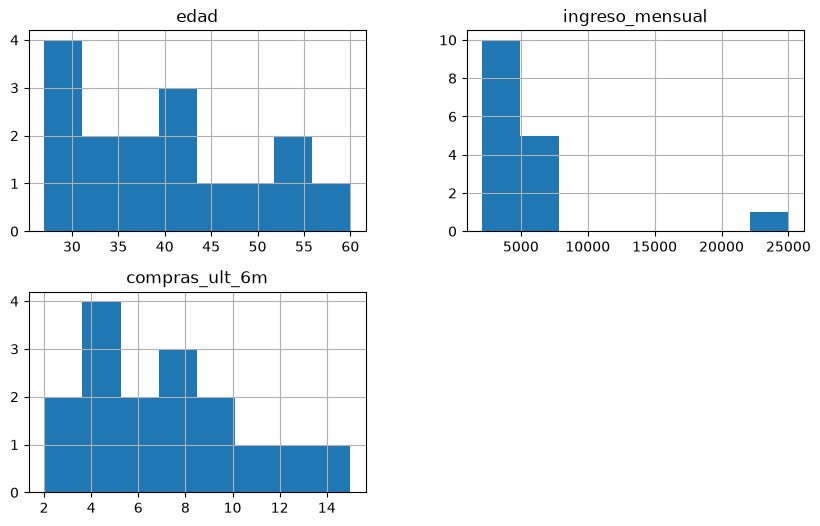

In [116]:
histogramas = df_limpio[numericas].hist(bins=8, figsize=(10, 6))  # Dibuja un histograma por columna numérica usando ocho intervalos.


### Diagramas de caja

El diagrama de caja muestra la mediana, los cuartiles y posibles valores extremos.
Cada variable tiene su propio eje porque sus unidades son diferentes.


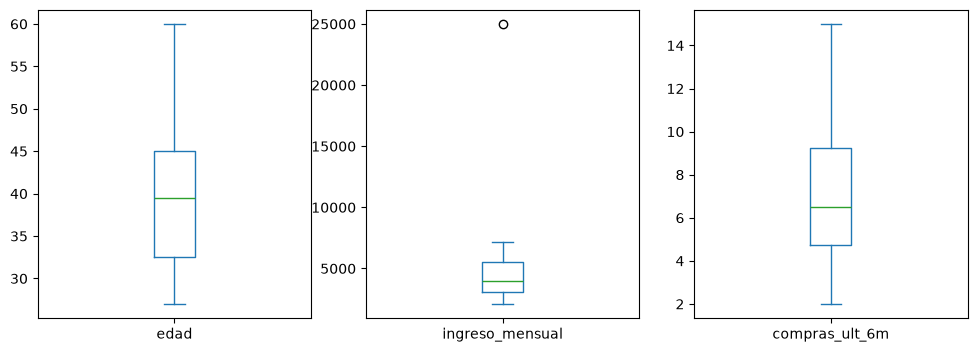

In [117]:
diagramas = df_limpio[numericas].plot.box(subplots=True, figsize=(12, 4), sharey=False)  # Dibuja un diagrama de caja por variable, con una escala vertical independiente.


## 6. Normalización y estandarización de `df_limpio`

El escalado se aplica solamente a las columnas numéricas de `df_limpio`. Las columnas de identificación y las variables categóricas se conservan sin cambios.

### 6.1 Normalización Min-Max

La normalización lleva cada variable al intervalo entre 0 y 1:

$$x_{normalizado} = \frac{x - x_{min}}{x_{max} - x_{min}}$$

El valor mínimo de cada columna queda en 0 y el máximo queda en 1.


In [ ]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler  # Importa los dos métodos de escalado.

columnas_numericas = df_limpio.select_dtypes(include="number").columns  # Detecta automáticamente las columnas numéricas.
          # Crea el transformador que llevará los datos al intervalo entre 0 y 1.
          # Conserva df_limpio sin modificaciones.
df_normalizado[columnas_numericas] = normalizador.fit_transform(df_limpio[columnas_numericas])  # Normaliza las columnas numéricas.

display(df_normalizado[columnas_numericas].agg(["min", "max"]).round(3))  # Verifica que cada columna esté entre 0 y 1.


,cliente_id,edad,ingreso_mensual,compras_ult_6m,canal,region,satisfaccion,fecha_alta,Servicio
0,C001,0.061,0.017,0.154,Web,Norte,media,2024-01-15,no
1,C002,0.424,0.087,0.462,Tienda,Sur,alta,2022-06-03,no
2,C003,0.390,0.149,0.231,App,Centro,media,2023-11-20,si
3,C004,0.242,0.061,0.308,web,Norte,baja,2025-02-10,si
4,C005,0.758,0.205,0.769,APP,Sur,alta,2021-08-25,no
5,C006,0.030,0.004,0.077,Tienda,Centro,baja,2025-05-12,si
6,C007,0.515,0.122,0.538,Web,Norte,alta,2022-12-01,no
7,C008,0.121,0.035,0.154,App,Centro,media,2024-07-18,si
8,C009,0.364,0.074,0.385,Tienda,Sur,media,2023-03-09,no
9,C010,1.000,1.000,1.000,Web,Norte,alta,2020-10-30,no


,edad,ingreso_mensual,compras_ult_6m
min,0.0,0.0,0.0
max,1.0,1.0,1.0


### 6.2 Estandarización Z-score

La estandarización centra cada variable alrededor de cero y la expresa en unidades de desviación estándar:

$$z = \frac{x - \mu}{\sigma}$$

Después de la transformación, cada columna tiene media cercana a 0 y desviación estándar poblacional cercana a 1.


In [ ]:
          # Crea el transformador Z-score.
          # Conserva df_limpio sin modificaciones.
          # Estandariza las columnas numéricas.

display(df_estandarizado.round(3))  # Muestra el DataFrame estandarizado con tres decimales.
resumen_estandarizacion = pd.DataFrame({  # Resume el resultado para comprobar la transformación.
    "media": df_estandarizado[columnas_numericas].mean(),
    "desviacion_estandar": df_estandarizado[columnas_numericas].std(ddof=0),
})
display(resumen_estandarizacion.round(3))  # Verifica medias de 0 y desviaciones estándar de 1.


,cliente_id,edad,ingreso_mensual,compras_ult_6m,canal,region,satisfaccion,fecha_alta,Servicio
0,C001,-1.138,-0.575,-0.915,Web,Norte,media,2024-01-15,no
1,C002,0.120,-0.271,0.253,Tienda,Sur,alta,2022-06-03,no
2,C003,-0.000,0.000,-0.623,App,Centro,media,2023-11-20,si
3,C004,-0.509,-0.385,-0.331,web,Norte,baja,2025-02-10,si
4,C005,1.273,0.243,1.421,APP,Sur,alta,2021-08-25,no
5,C006,-1.243,-0.632,-1.207,Tienda,Centro,baja,2025-05-12,si
6,C007,0.434,-0.118,0.545,Web,Norte,alta,2022-12-01,no
7,C008,-0.929,-0.499,-0.915,App,Centro,media,2024-07-18,si
8,C009,-0.090,-0.328,-0.039,Tienda,Sur,media,2023-03-09,no
9,C010,2.112,3.708,2.297,Web,Norte,alta,2020-10-30,no


,media,desviacion_estandar
edad,-0.0,1.0
ingreso_mensual,-0.0,1.0
compras_ult_6m,0.0,1.0
